# EE 344 — Assignment 6: Power Quality Fault Detection

In this assignment, you will build a structured pipeline for **power quality fault detection** using both supervised and unsupervised learning methods.

You will:
- Preprocess data (OHE + Robust Scaling)
- Perform nonlinear dimensionality reduction (KPCA)
- Train a bottleneck Autoencoder
- Visualize embeddings (3D and t-SNE)
- Apply Kernel SVM for classification
- Perform clustering (K-Means and GMM)
- Compare clustering purity against known labels

Follow instructions carefully.  
Do not modify the provided structure.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Dataset and Basic Statistics

- Load the dataset file.
- Print shape, columns, missing values.
- Print numeric summary statistics.
- Print label distribution.


In [3]:
# --------------------
# 0) Load the dataset
# --------------------
CSV_PATH = "power_quality_fault_dataset.csv"  # Kaggle dataset file name (same as provided file)
df = pd.read_csv(CSV_PATH)

print("Shape (rows, cols):", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nMissing values per column:")
print(df.isna().sum())

print("\nNumeric summary (describe):")
print(df.describe(include=[np.number]).T)

# Adjust if your CSV uses different names
LABEL_COL = "Fault_Type"
CAT_COL   = "Phase"

print("\nLabel distribution:")
print(df[LABEL_COL].value_counts())

print("\nPhase distribution:")
print(df[CAT_COL].value_counts())

Shape (rows, cols): (2367, 12)

Columns: ['ID', 'Fault_Type', 'Phase', 'RMS_Voltage', 'Peak_Voltage', 'THD', 'Duration_ms', 'DWT_Energy_Level1', 'DWT_Energy_Level2', 'DWT_Entropy', 'Signal_Noise_Ratio_dB', 'Label']

Missing values per column:
ID                       0
Fault_Type               0
Phase                    0
RMS_Voltage              0
Peak_Voltage             0
THD                      0
Duration_ms              0
DWT_Energy_Level1        0
DWT_Energy_Level2        0
DWT_Entropy              0
Signal_Noise_Ratio_dB    0
Label                    0
dtype: int64

Numeric summary (describe):
                        count         mean         std     min      25%  \
ID                     2367.0  1184.000000  683.438366    1.00  592.500   
RMS_Voltage            2367.0   221.905327   39.640015  113.99  223.625   
Peak_Voltage           2367.0   328.814812   66.782209  161.21  317.650   
THD                    2367.0     4.742281    3.329978   -0.25    2.400   
Duration_ms     

## 2. Train/Test Split + Encoding

- Stratify using (Fault_Type, Phase)
- One-Hot Encode Phase (fit on train only)
- Robust scale numeric features only


In [7]:
# --------------------
# 1) Drop columns
# --------------------
DROP_COLS = ["ID", "Label"]  # typical in this dataset; safe to ignore if absent
DROP_COLS = [c for c in DROP_COLS if c in df.columns]
df = df.drop(columns=DROP_COLS)

# --------------------
# 2) Train/test split
# Stratify on joint (Fault_Type, Phase) to preserve both distributions
# --------------------
strata = df[LABEL_COL].astype(str) + "|" + df[CAT_COL].astype(str)

train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=strata
)

print("Train shape:", train_df.shape, " Test shape:", test_df.shape)

Train shape: (1656, 10)  Test shape: (711, 10)


In [9]:
# --------------------
# 3) Encode Fault_Type -> integer labels
# --------------------
target_names = sorted(df[LABEL_COL].unique())
label_map = {name: i for i, name in enumerate(target_names)}

y_train = train_df[LABEL_COL].map(label_map).to_numpy()
y_test  = test_df[LABEL_COL].map(label_map).to_numpy()

print("Label map:", label_map)

# --------------------
# 4) One-hot encode Phase (fit on train only)
# --------------------
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
phase_train_ohe = ohe.fit_transform(train_df[[CAT_COL]])
phase_test_ohe  = ohe.transform(test_df[[CAT_COL]])
phase_cols = ohe.get_feature_names_out([CAT_COL])

# --------------------
# 5) Build numeric matrices (drop label + phase)
# --------------------
X_train_num = train_df.drop(columns=[LABEL_COL, CAT_COL])
X_test_num  = test_df.drop(columns=[LABEL_COL, CAT_COL])

# --------------------
# 6) Robust scale ONLY numeric features, then append OHE as-is
# --------------------
scaler = RobustScaler()
X_train_num_s = scaler.fit_transform(X_train_num)
X_test_num_s  = scaler.transform(X_test_num)

X_train_scaled = pd.concat(
    [
        pd.DataFrame(X_train_num_s, columns=X_train_num.columns).reset_index(drop=True),
        pd.DataFrame(phase_train_ohe, columns=phase_cols).reset_index(drop=True),
    ],
    axis=1
)

X_test_scaled = pd.concat(
    [
        pd.DataFrame(X_test_num_s, columns=X_test_num.columns).reset_index(drop=True),
        pd.DataFrame(phase_test_ohe, columns=phase_cols).reset_index(drop=True),
    ],
    axis=1
)

print("X_train_scaled:", X_train_scaled.shape, " y_train:", y_train.shape)
print("X_test_scaled :", X_test_scaled.shape,  " y_test :", y_test.shape)
print("OHE phase cols:", list(phase_cols))

Label map: {'Harmonics': 0, 'Normal': 1, 'Sag': 2, 'Swell': 3, 'Transient': 4}
X_train_scaled: (1656, 11)  y_train: (1656,)
X_test_scaled : (711, 11)  y_test : (711,)
OHE phase cols: ['Phase_A', 'Phase_B', 'Phase_C']


## Shared Utilities

In [12]:
def eval_classifier(clf, Xtr, ytr, Xte, yte, *, title="Model"):
    clf.fit(Xtr, ytr)

    yhat_tr = clf.predict(Xtr)
    yhat_te = clf.predict(Xte)

    print(f"\n================ {title} ================")

    print("\n--- TRAIN ---")
    print(classification_report(ytr, yhat_tr, target_names=target_names))
    print("Confusion matrix (train):")
    print(confusion_matrix(ytr, yhat_tr))

    print("\n--- TEST ---")
    print(classification_report(yte, yhat_te, target_names=target_names))
    print("Confusion matrix (test):")
    print(confusion_matrix(yte, yhat_te))


def scatter_2d(Z, y, title, xlab="z1", ylab="z2"):
    plt.figure(figsize=(6, 5))
    for i, name in enumerate(target_names):
        m = (y == i)
        plt.scatter(Z[m, 0], Z[m, 1], s=12, label=name)
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.legend(title=LABEL_COL, markerscale=1.2, frameon=True)
    plt.show()


def scatter_3d(Z, y, title, xlab="z1", ylab="z2", zlab="z3"):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    for i, name in enumerate(target_names):
        m = (y == i)
        ax.scatter(Z[m, 0], Z[m, 1], Z[m, 2], s=12, label=name)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_zlabel(zlab)
    ax.legend(title=LABEL_COL, markerscale=1.2, frameon=True)
    plt.show()

## Part 1 – KPCA (3D) + Kernel SVM (RBF)

**Idea:**  
Kernel PCA uses a **kernel function** (here, RBF) to implicitly map data into a higher-dimensional feature space, then performs PCA there. The goal is to obtain a **low-dimensional embedding** that can reveal structure that is not visible with linear PCA.

This “kernel trick” idea is also used by several classifiers. For example, an **RBF Kernel SVM** also uses an implicit high-dimensional mapping, but instead of PCA it searches for a **linear separating hyperplane in that feature space** (which corresponds to a nonlinear boundary in the original space).

### Tasks
1. Apply Kernel PCA with RBF kernel to reduce data to 3 dimensions.
2. Visualize train embedding in 3D.
3. Train an RBF Kernel SVM using the KPCA features.
4. Print classification report and confusion matrix for train and test.

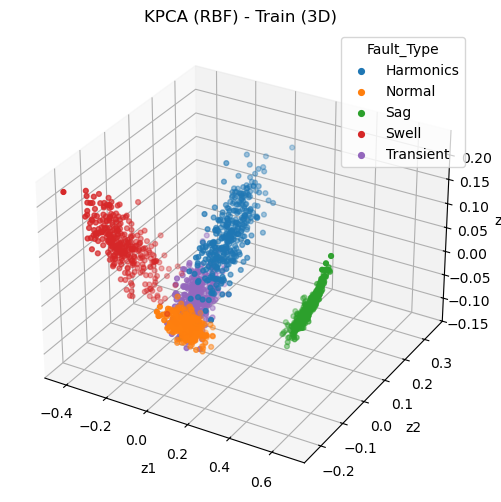

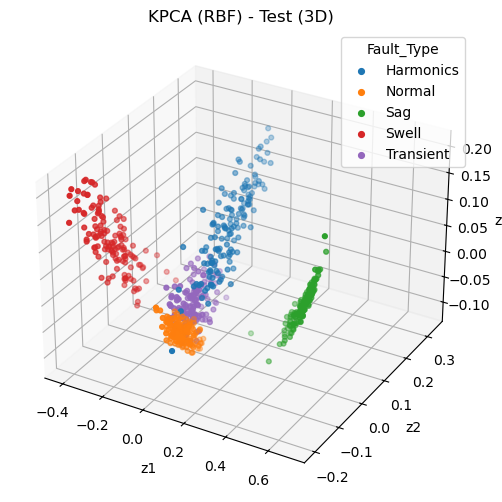


================ KPCA(3D) + RBF-SVM ================

--- TRAIN ---
              precision    recall  f1-score   support

   Harmonics       0.97      0.95      0.96       339
      Normal       0.96      1.00      0.98       345
         Sag       1.00      1.00      1.00       327
       Swell       1.00      0.99      1.00       315
   Transient       0.96      0.94      0.95       330

    accuracy                           0.98      1656
   macro avg       0.98      0.98      0.98      1656
weighted avg       0.98      0.98      0.98      1656

Confusion matrix (train):
[[322   4   0   0  13]
 [  0 345   0   0   0]
 [  0   0 327   0   0]
 [  1   1   0 312   1]
 [ 10   9   0   0 311]]

--- TEST ---
              precision    recall  f1-score   support

   Harmonics       0.98      0.97      0.98       146
      Normal       0.97      1.00      0.98       147
         Sag       1.00      1.00      1.00       140
       Swell       1.00      0.99      1.00       135
   Transient   

In [15]:
from sklearn.decomposition import KernelPCA
from sklearn.svm import SVC

Xtr = X_train_scaled.to_numpy(dtype=np.float32)
Xte = X_test_scaled.to_numpy(dtype=np.float32)

# -------------------------
# TODO 1A: KPCA (RBF) 3D
# -------------------------
kpca3 = KernelPCA(
    n_components=3,
    kernel="rbf",
    gamma=0.005,
    random_state=42
)

# Fit ONLY on training data
Z_kpca3_train = kpca3.fit_transform(Xtr)

# Transform test data using same mapping
Z_kpca3_test = kpca3.transform(Xte)

# -------------------------
# Provided: visualization
# -------------------------
scatter_3d(Z_kpca3_train, y_train, "KPCA (RBF) - Train (3D)")
scatter_3d(Z_kpca3_test,  y_test,  "KPCA (RBF) - Test (3D)")

# -------------------------
# TODO 1B: Kernel SVM (RBF) on KPCA features
# -------------------------
svm_rbf_kpca = SVC(
    kernel="rbf",
    C=10.0,
    gamma="scale",
    random_state=42
)

eval_classifier(
    svm_rbf_kpca,
    Z_kpca3_train, y_train,
    Z_kpca3_test,  y_test,
    title="KPCA(3D) + RBF-SVM"
)

## Part 2 – Autoencoder Embedding (3D) + Kernel SVM (RBF)

In this part, you will train a **multi-head autoencoder** that reconstructs:
- the **numeric features** (MSE), and
- the **phase category** (cross-entropy on phase logits).

You will use the **3D bottleneck** as a learned embedding for:
- 3D visualization, and
- RBF Kernel SVM classification.

### Architecture (Encoder/Decoder)
- Encoder: `input_dim → 6 → 3`
- Decoder trunk: `3 → 6 → { numeric head, phase head }`

**Important:**
- Use **BatchNorm + Dropout** in the hidden layers.
- Use **no activation on the bottleneck** (linear only).
- Train with `lr = 1e-2`, `batch_size = 512`.
- Print **average epoch loss** every `100` epochs.

### Tasks
1. Prepare numeric vs phase parts of the input (phase index labels from one-hot).
2. Implement the `MultiHeadAE` model (encoder + 2 decoder heads).
3. Implement the training loop (MSE + λ·CE) and print average epoch loss.
4. Train the model with `latent_dim = 3` and visualize the embedding (3D).
5. Train an **RBF Kernel SVM** on the learned 3D embeddings and report:
   - confusion matrix + classification report (train and test).

In [18]:
# ===== Autoencoder 3D (BN+Dropout; NOTHING on bottleneck)
# Required:
#   - lr = 1e-2
#   - batch_size = 512
#   - print average epoch loss every 100 epochs

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Assumes you already have:
# - X_train_scaled, X_test_scaled (pandas DataFrame or numpy array)
# - phase_cols (list of OHE phase columns, same order used in X_train_scaled)
# - y_train, y_test, target_names

phase_cols = list(phase_cols)
n_cat = len(phase_cols)

Xtr = np.asarray(X_train_scaled, dtype=np.float32)
Xte = np.asarray(X_test_scaled,  dtype=np.float32)

n_total = Xtr.shape[1]
n_num = n_total - n_cat

# Numeric portion (for MSE recon)
Xtr_num = Xtr[:, :n_num]
Xte_num = Xte[:, :n_num]

# Phase index labels (for CE on phase logits)
tr_phase_idx = Xtr[:, n_num:].argmax(axis=1).astype(np.int64)
te_phase_idx = Xte[:, n_num:].argmax(axis=1).astype(np.int64)

# Torch tensors (keep on CPU; move per-batch to device in training loop)
Xtr_t = torch.from_numpy(Xtr)
Xte_t = torch.from_numpy(Xte)

Xtr_num_t = torch.from_numpy(Xtr_num)
Xte_num_t = torch.from_numpy(Xte_num)

tr_phase_idx_t = torch.from_numpy(tr_phase_idx)
te_phase_idx_t = torch.from_numpy(te_phase_idx)

print("n_total:", n_total, "| n_num:", n_num, "| n_cat:", n_cat)

Device: cpu
n_total: 11 | n_num: 8 | n_cat: 3


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, n_num, n_cat, p_drop=0.1):
        super().__init__()

        # -------------------------
        # Encoder
        # -------------------------
        self.enc_fc1 = nn.Linear(input_dim, hidden_dim)
        self.enc_bn1 = nn.BatchNorm1d(hidden_dim)
        self.enc_do1 = nn.Dropout(p_drop)
        self.enc_fc2 = nn.Linear(hidden_dim, latent_dim)  # bottleneck (no activation)

        # -------------------------
        # Decoder trunk
        # -------------------------
        self.dec_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.dec_bn1 = nn.BatchNorm1d(hidden_dim)
        self.dec_do1 = nn.Dropout(p_drop)

        # -------------------------
        # Decoder heads
        # -------------------------
        self.dec_num = nn.Linear(hidden_dim, n_num)  # regression
        self.dec_cat = nn.Linear(hidden_dim, n_cat)  # logits (no softmax)

    def encode(self, x):
        h = self.enc_fc1(x)
        h = self.enc_bn1(h)
        h = F.relu(h)
        h = self.enc_do1(h)
        z = self.enc_fc2(h)  # no activation here
        return z

    def forward(self, x):
        # Encode
        z = self.encode(x)

        # Decode trunk
        h = self.dec_fc1(z)
        h = self.dec_bn1(h)
        h = F.relu(h)
        h = self.dec_do1(h)

        # Heads
        x_num_hat = self.dec_num(h)
        phase_logits = self.dec_cat(h)

        return z, x_num_hat, phase_logits

In [24]:
def train_and_embed(
    *,
    epochs=1000,
    batch_size=512,
    lr=1e-2,
    lambda_ce=0.005,
    print_every=100
):
    model = MultiHeadAE(
        input_dim=n_total,
        hidden_dim=6,
        latent_dim=3,
        n_num=n_num,
        n_cat=n_cat,
        p_drop=0.1
    ).to(device)

    mse = nn.MSELoss()
    ce  = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    ds = TensorDataset(Xtr_t, Xtr_num_t, tr_phase_idx_t)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0

        for xb, xb_num, ph_idx in dl:
            xb = xb.to(device)
            xb_num = xb_num.to(device)
            ph_idx = ph_idx.to(device)

            # Forward
            z, x_num_hat, phase_logits = model(xb)

            # Loss
            loss = mse(x_num_hat, xb_num) + lambda_ce * ce(phase_logits, ph_idx)

            # Backprop
            opt.zero_grad()
            loss.backward()
            opt.step()

            # Accumulate (scale by batch size)
            total_loss += loss.item() * xb.size(0)

        if (epoch % print_every) == 0 or epoch == 1:
            avg_loss = total_loss / len(ds)
            print(f"Epoch {epoch:04d}/{epochs} | loss={avg_loss:.6f}")

    model.eval()
    with torch.no_grad():
        # Encode embeddings
        Ztr = model.encode(Xtr_t.to(device)).cpu()
        Zte = model.encode(Xte_t.to(device)).cpu()

    return model, Ztr, Zte

Epoch 0001/1000 | loss=1.598281
Epoch 0100/1000 | loss=0.375022
Epoch 0200/1000 | loss=0.383452
Epoch 0300/1000 | loss=0.390621
Epoch 0400/1000 | loss=0.380005
Epoch 0500/1000 | loss=0.379515
Epoch 0600/1000 | loss=0.375605
Epoch 0700/1000 | loss=0.390800
Epoch 0800/1000 | loss=0.377095
Epoch 0900/1000 | loss=0.376319
Epoch 1000/1000 | loss=0.373767


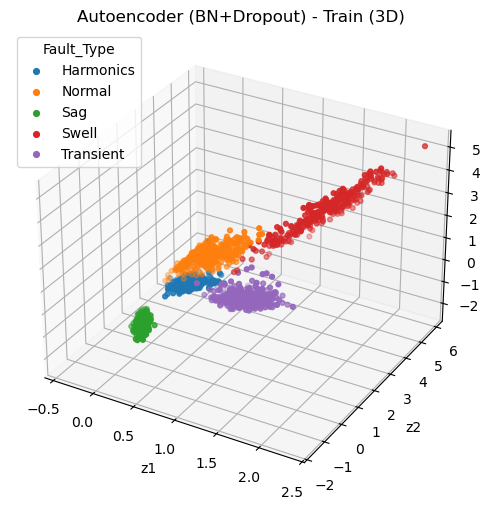

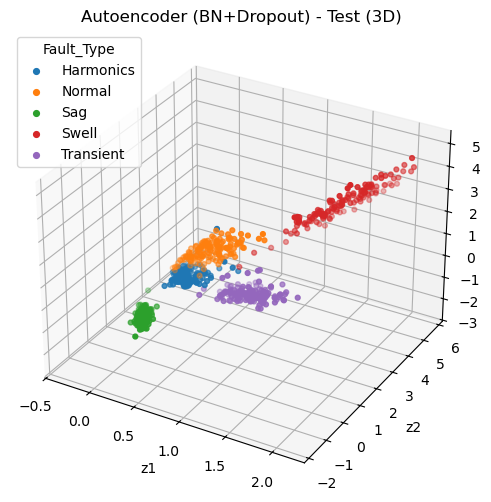


================ AE(3D) + RBF-SVM ================

--- TRAIN ---
              precision    recall  f1-score   support

   Harmonics       0.99      0.99      0.99       339
      Normal       0.97      1.00      0.99       345
         Sag       1.00      1.00      1.00       327
       Swell       1.00      0.99      0.99       315
   Transient       1.00      0.99      0.99       330

    accuracy                           0.99      1656
   macro avg       0.99      0.99      0.99      1656
weighted avg       0.99      0.99      0.99      1656

Confusion matrix (train):
[[335   4   0   0   0]
 [  0 345   0   0   0]
 [  0   0 327   0   0]
 [  1   3   0 311   0]
 [  1   3   0   0 326]]

--- TEST ---
              precision    recall  f1-score   support

   Harmonics       0.99      0.99      0.99       146
      Normal       0.99      1.00      0.99       147
         Sag       1.00      1.00      1.00       140
       Swell       1.00      0.99      1.00       135
   Transient     

In [26]:
from sklearn.svm import SVC

# -------------------------
# TODO 2H: Train AE and get 3D embeddings
# -------------------------
model, Z_ae3_train, Z_ae3_test = train_and_embed(
    epochs=1000,
    lr=1e-2,
    batch_size=512,
    lambda_ce=0.005
)

# If tensors, convert to numpy for sklearn
Z_ae3_train = Z_ae3_train.numpy()
Z_ae3_test  = Z_ae3_test.numpy()

scatter_3d(Z_ae3_train, y_train, "Autoencoder (BN+Dropout) - Train (3D)")
scatter_3d(Z_ae3_test,  y_test,  "Autoencoder (BN+Dropout) - Test (3D)")

# -------------------------
# TODO 2I: Kernel SVM (RBF) on AE embeddings
# -------------------------
svm_rbf_ae = SVC(
    kernel="rbf",
    C=10.0,
    gamma="scale",
    random_state=42
)

eval_classifier(
    svm_rbf_ae,
    Z_ae3_train, y_train,
    Z_ae3_test,  y_test,
    title="AE(3D) + RBF-SVM"
)

## Part 3 – t-SNE (2D)

### Tasks
- Apply t-SNE (2D) on robust-scaled train data.
- Visualize class separation.


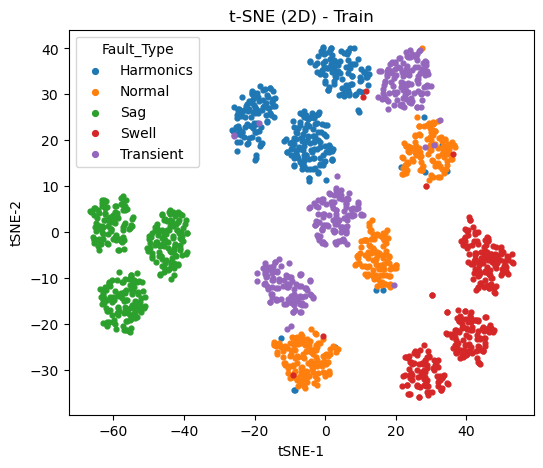

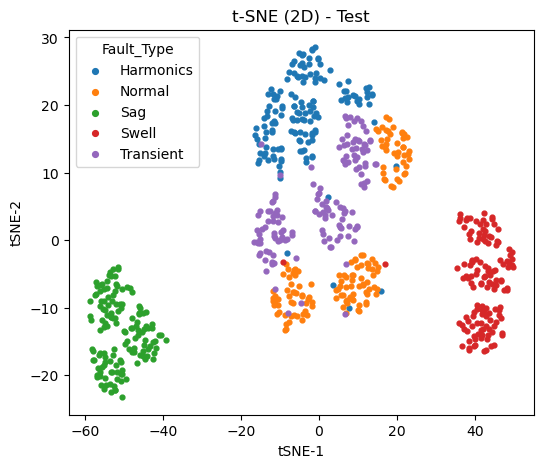

In [28]:
from sklearn.manifold import TSNE

# -------------------------
# TODO 3A: t-SNE 2D on train
# -------------------------
tsne_tr = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)

Z_tsne_train = tsne_tr.fit_transform(Xtr)

scatter_2d(Z_tsne_train, y_train, "t-SNE (2D) - Train", xlab="tSNE-1", ylab="tSNE-2")

# -------------------------
# TODO 3B: t-SNE 2D on test (fit separately)
# -------------------------
tsne_te = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)

Z_tsne_test = tsne_te.fit_transform(Xte)

scatter_2d(Z_tsne_test, y_test, "t-SNE (2D) - Test", xlab="tSNE-1", ylab="tSNE-2")

## Part 4 – K-Means Clustering

### Tasks
- Compute WCSS for k=2 to 15.
- Compute Silhouette score.
- Compute Fowlkes-Mallows Index.
- Identify best k.
- Print within-cluster class distribution (percentage).


In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, fowlkes_mallows_score

k_values = list(range(2, 16))

wcss = []
sil = []
fmi = []

for k in k_values:
    # Initialize
    km = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )

    # Fit + predict cluster labels
    c_tr = km.fit_predict(Xtr)

    # WCSS (inertia)
    wcss.append(km.inertia_)

    # Silhouette score (only valid if >1 cluster and < n_samples)
    sil.append(silhouette_score(Xtr, c_tr))

    # Fowlkes–Mallows Index (compare to ground truth labels)
    fmi.append(fowlkes_mallows_score(y_train, c_tr))

In [43]:
BEST_K =  5 # <--- Set after inspecting curves

km = KMeans(n_clusters=BEST_K, n_init=50, random_state=RANDOM_STATE)
c_tr = km.fit_predict(X_train_scaled)
c_te = km.predict(X_test_scaled)

def cluster_purity_percent(clusters, y, split_name):
    tab = pd.crosstab(
        pd.Series(clusters, name="Cluster"),
        pd.Series([target_names[i] for i in y], name="Class")
    )
    tab["Total"] = tab.sum(axis=1)

    pct = (tab.drop(columns=["Total"]).div(tab["Total"], axis=0) * 100).round(2)
    print(f"\n=== {split_name}: within-cluster class % ===")
    print(pct)

cluster_purity_percent(c_tr, y_train, "TRAIN")
cluster_purity_percent(c_te, y_test,  "TEST")


=== TRAIN: within-cluster class % ===
Class    Harmonics  Normal    Sag   Swell  Transient
Cluster                                             
0             0.00    0.00    0.0  100.00       0.00
1             0.00    0.00  100.0    0.00       0.00
2            99.35    0.00    0.0    0.00       0.65
3             5.70   89.38    0.0    2.33       2.59
4             3.31    0.00    0.0    0.90      95.78

=== TEST: within-cluster class % ===
Class    Harmonics  Normal    Sag   Swell  Transient
Cluster                                             
0             0.00     0.0    0.0  100.00       0.00
1             0.00     0.0  100.0    0.00       0.00
2           100.00     0.0    0.0    0.00       0.00
3             8.93    87.5    0.6    0.00       2.98
4             0.00     0.0    0.0    1.43      98.57


## Part 5 – Gaussian Mixture Model

### Tasks
- Compute BIC and AIC for k=1 to 15.
- Compute Fowlkes-Mallows Index.
- Identify best k.
- Print within-cluster class distribution (percentage).


In [60]:
def plot_k_curve(k_vals, ys, title, ylab):
    plt.figure(figsize=(6,4))
    plt.plot(k_vals, ys, marker="o")   # no extra string here!
    plt.title(title)
    plt.xlabel("k")
    plt.ylabel(ylab)
    plt.grid(True, alpha=0.3)
    plt.show()

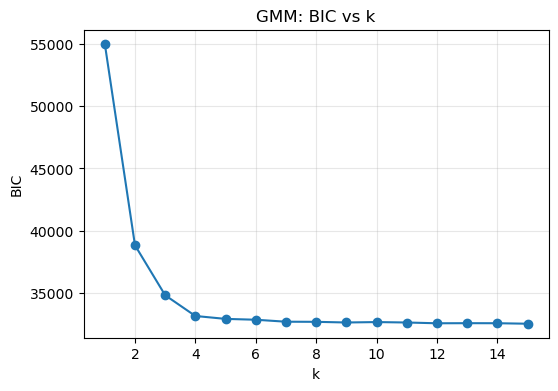

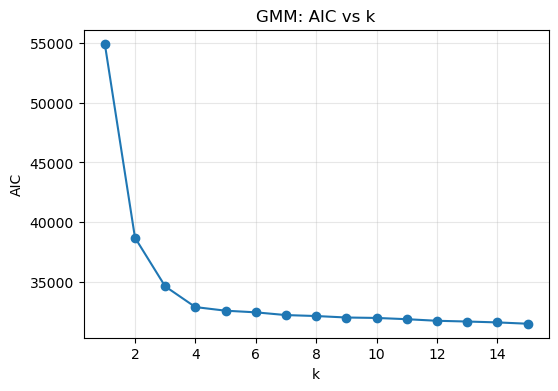

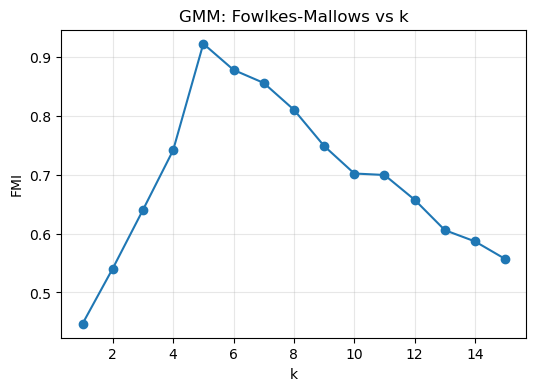

     k           bic           aic       fmi
0    1  55009.132478  54944.186554  0.446890
1    2  38832.484489  38697.180481  0.540796
2    3  34824.237502  34618.575409  0.640393
3    4  33159.187810  32883.167633  0.741878
4    5  32927.035732  32580.657471  0.923141
5    6  32858.781817  32442.045471  0.878633
6    7  32700.227563  32213.133133  0.856448
7    8  32690.555633  32133.103119  0.810853
8    9  32637.500754  32009.690155  0.749237
9   10  32671.259153  31973.090469  0.702395
10  11  32636.779819  31868.253052  0.699891
11  12  32574.255549  31735.370697  0.657673
12  13  32582.113679  31672.870743  0.606018
13  14  32578.777839  31599.176819  0.586815
14  15  32538.783644  31488.824539  0.556915


In [62]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import fowlkes_mallows_score

k_values = list(range(1, 16))
bic = []
aic = []
fmi = []

COV_TYPE = "spherical"  # could also try "diag", "tied", "spherical"

for k in k_values:
    # Initialize GMM
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=COV_TYPE,
        n_init=20,
        max_iter = 100,
        random_state=42
    )

    # Fit + predict cluster assignments
    c_tr = gmm.fit_predict(Xtr)

    # Append metrics
    bic.append(gmm.bic(Xtr))
    aic.append(gmm.aic(Xtr))
    fmi.append(fowlkes_mallows_score(y_train, c_tr))

# Plot curves
plot_k_curve(k_values, bic, "GMM: BIC vs k", "BIC")
plot_k_curve(k_values, aic, "GMM: AIC vs k", "AIC")
plot_k_curve(k_values, fmi, "GMM: Fowlkes-Mallows vs k", "FMI")

# Table
results_gmm = pd.DataFrame({"k": k_values, "bic": bic, "aic": aic, "fmi": fmi})
print(results_gmm)

In [64]:
BEST_K =  5 # <--- Set after inspecting BIC/AIC

gmm = GaussianMixture(
    n_components=BEST_K,
    covariance_type=COV_TYPE,
    n_init=50,
    random_state=RANDOM_STATE
)
gmm.fit(X_train_scaled)

c_tr = gmm.predict(X_train_scaled)
c_te = gmm.predict(X_test_scaled)

cluster_purity_percent(c_tr, y_train, "TRAIN (GMM)")
cluster_purity_percent(c_te, y_test,  "TEST (GMM)")


=== TRAIN (GMM): within-cluster class % ===
Class    Harmonics  Normal    Sag   Swell  Transient
Cluster                                             
0             0.00    0.00  100.0    0.00       0.00
1            99.35    0.00    0.0    0.00       0.65
2             3.06    0.00    0.0    0.92      96.02
3             0.00    0.00    0.0  100.00       0.00
4             6.35   87.56    0.0    2.54       3.55

=== TEST (GMM): within-cluster class % ===
Class    Harmonics  Normal     Sag   Swell  Transient
Cluster                                              
0             0.00    0.00  100.00    0.00       0.00
1           100.00    0.00    0.00    0.00       0.00
2             1.43    0.00    0.00    1.43      97.14
3             0.00    0.00    0.00  100.00       0.00
4             9.36   85.96    0.58    0.00       4.09


## Part 6 – Discussion

Compare K-Means vs GMM clustering on this dataset where the true labels are known.

Focus on:
1) Whether clusters look “pure” (one dominant class per cluster),
2) Whether the best k is close to the number of true classes,
3) How consistent the cluster purity is between train and test.

Which clustering method is better here, and why?


1. Cluster Purity

Both algorithms tend to form mostly pure clusters. With k = 5, most clusters are dominated by a single class, with over 95% purity. The only exception is the 'Normal' class, which has some impurities, i.e., 12% of other classes are present. However, the 'Normal' class is slightly better clustered by the GMM algorithm, which is likely due to the probabilistic assignment of the algorithm, allowing it to handle the overlapping points. All other classes, i.e., 'Harmonics', 'Sag', 'Swell', 'Transient', form highly pure clusters with both the algorithms, showing that the algorithms are effective at capturing the main structure of the data.

---

2. Best k vs True Classes

In both cases, for both KMeans and GMM, the optimal value of *k* is very close to the actual number of classes in the data. **k = 5**. This suggests that the data has an intrinsic structure that allows it to be divided into five classes. In other words, neither of these methods over- or under-estimates the number of clusters. The similarity of these results confirms that both of these methods effectively capture the intrinsic dimensionality of the data.

---

3. Consistency Between Train and Test

The purity of the clusters is consistent when using both methods on training as well as test sets. There are small fluctuations, especially in “Normal” and “Transient” clusters, but GMM is more consistent. The reason is that GMM is able to handle overlapping clusters probabilistically, while K-Means has hard boundaries that are spherical in shape. Both methods are able to generalize well, but GMM is slightly better because it is probabilistic.
